# Hypothesis Testing Homework

In this lab you will explore doing some of your own statistics with regards to the `pvd_arrests` and `pvd_cases` data. For each question, please provide:

 * reproducible code to arrive at your answer
 * your thought process on the code and statistical test you chose
 * an exploratory data visualization associated with the question
 * your response to the overall question
 
 There will not necessarily be any right ways to answer the questions (although there will certainly be wrong ways), so don't worry about making sure your answer is perfect.

In [3]:
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")
cases_df = read.csv("pvd_cases_2021-10-03.csv")

## 1. National arrest rate

The national arrest rate was 2312.2 per 100,000 individuals in 2021 [according to the FBI](https://www.statista.com/statistics/191267/arrest-rate-for-all-offenses-in-the-us-since-1990/#:~:text=In%202022%2C%20the%20arrest%20rate,per%20100%2C000%20of%20the%20population). Was the national arrest rate in Providence in 2020 significantly different from the national average? Please cite any additional data sources used to answer this question.

In [4]:
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")
df_distinct <- arrests_df %>% distinct (arrest_date, .keep_all =TRUE) #add distinct on arrest date, keep_all = true
total_arrests <- df_distinct %>%
    filter(year == 2020) %>%
    summarize(n = n())  

In [6]:
PVD_pop <- 190934 #https://www.census.gov/quickfacts/fact/table/providencecityrhodeisland/POP010220
national_rate <- 2312.2/100000 
n_trials <- PVD_pop #I used chatgpt to figure out how to do the expected arrest calculation for PVD based on the national rate. I got stuck figuring out how to structure this
observed_arrests <- total_arrests$n

test <- binom.test (observed_arrests,n_trials, p = national_rate, alternative = "two.sided") #change this just the PVD tghen compare result to national
print (test)
#Yes, PVD arrest was significantly lower than the national average in 2020


	Exact binomial test

data:  observed_arrests and n_trials
number of successes = 2974, number of trials = 190934, p-value <
2.2e-16
alternative hypothesis: true probability of success is not equal to 0.023122
95 percent confidence interval:
 0.01502538 0.01614152
sample estimates:
probability of success 
            0.01557606 



In [7]:
#chat gpt said to calculate an expected arrests for this and not just use the national number with a proportion in the data frame like I had been
expected <- national_rate*PVD_pop

Visual <- data.frame(
    location = c( "providence", "national"),
    arrests = c(total_arrests$n, expected)
    )
print (Visual)       

    location  arrests
1 providence 2974.000
2   national 4414.776


In [8]:
head(Visual)

,location,arrests
,<chr>,<dbl>
1,providence,2974.000
2,national,4414.776


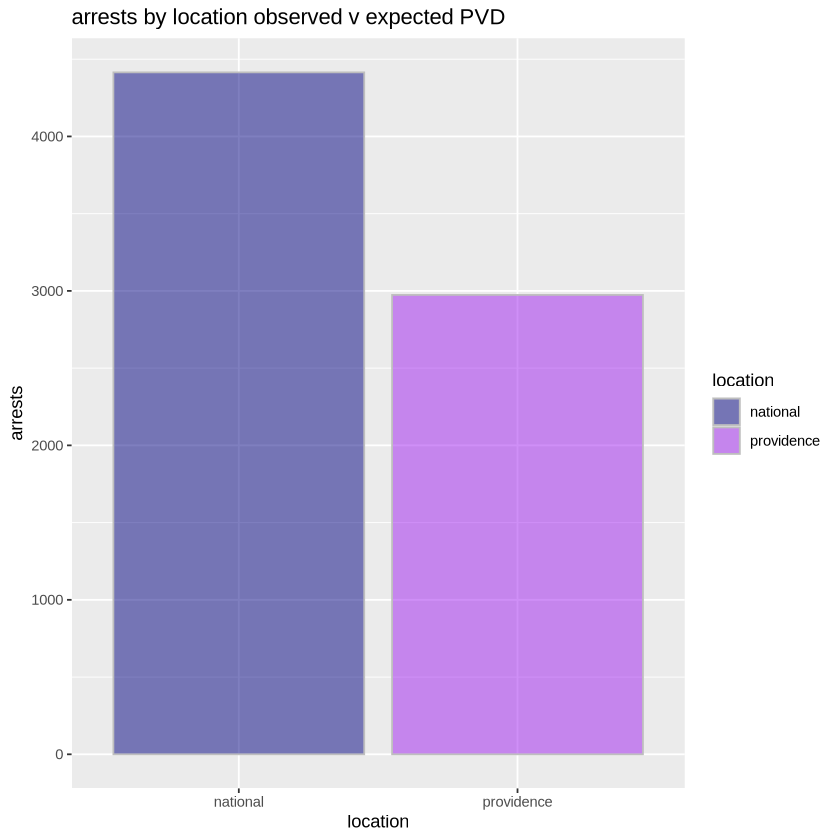

In [9]:
ggplot(Visual, aes(x = location, y = arrests, fill = location)) +
    geom_bar(stat ="identity",alpha = 0.5, colour = "grey") + #i kept getting errors, chat gpt said I needed to add "stat ="identity""
    labs(x="location", y= "arrests", title = "arrests by location observed v expected PVD" ) +
    scale_fill_manual(values = c("navy", "purple"))

In [10]:
#My approach:
#I filtered the data to only include 2020 data, found distinct arrests, and then pulled the total  number of arrests
#I wanted to get the national arrest rate against the population of PVD in 2020.
#I used the binom.test from class- and found arrests were significantly lower in PVD
#The binom structure I used r help on the internet mostly, and class help. I did my observed PVD arrests, the total PVD population, p= the national arrest average, and set it to greater. 
#Then, based on Chat GPT suggestion, I calculated expected PVD arrests based off national rates 
#The visual then compared expected v actual PVD arrests, and I added stat Identity based off Chat GPT

## 2. Seasonality of crime

The theory of the seasonality of crime was proposed by Belgian statistician Adolphe Quetelet in 1842 and aspects of the theory continues to be under active investigation today ([Delgado and Sanchez-Delgado 2023]((https://pmc.ncbi.nlm.nih.gov/articles/PMC10231786/)),[Shiode et al. 2023](https://link.springer.com/article/10.1007/s43762-023-00094-x)). The theory posits that there is a relationship between hot weather (or seasons), and crime rates. (This theory was the start of "moral science" and much of Quetelet's work also played a key role in the origin of eugenics)

Assuming our cases and arrests data can serve as proxies for crime, is there a relationship between seasonality and crime in Providence?

In [31]:
#head(arrests_df)
#weight my months by season

In [32]:
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")
df_distinct <- arrests_df %>% distinct (arrest_date, .keep_all =TRUE)
season_name <- c(rep("fall", 3), rep("winter", 3), rep("spring", 3), rep("summer", 3))
month_number<- c(9,10,11,12,1,2,3,4,5,6,7,8)
season_mapping <- data.frame(month = month_number, season = season_name) #I used chat gpt to use and understand my mapping here
arrests_df$season <- season_mapping$season [match(arrests_df$month, season_mapping$month)] # Like above, I used the internet and chat gpt to do the match function syntax
season_arrests<- table (arrests_df$season)


In [33]:
months_weight <- arrests_df %>%
group_by (year,month,) %>%
summarise(arrest_count =n(), .groups= "drop") #the error term told me i needed .groups- why?
print (months_weight)


# A tibble: 28 × 3
    year month arrest_count
   <int> <int>        <int>
 1  2019     7          541
 2  2019     8          652
 3  2019     9          610
 4  2019    10          639
 5  2019    11          651
 6  2019    12          900
 7  2020     1         1202
 8  2020     2          569
 9  2020     3          590
10  2020     4          362
# ℹ 18 more rows


In [34]:
total_arrests <- sum(season_arrests)
summer_arrests <- season_arrests ["summer"]
expected <- 2/10 #10 months in the dataset
test <- binom.test(summer_arrests, total_arrests, p = expected, alternative = "two.sided")
print (test)
#yes there is a relationship, there is a positive relationship between the season summer and crime 


	Exact binomial test

data:  summer_arrests and total_arrests
number of successes = 3550, number of trials = 13012, p-value < 2.2e-16
alternative hypothesis: true probability of success is not equal to 0.2
95 percent confidence interval:
 0.2651850 0.2805669
sample estimates:
probability of success 
             0.2728251 



In [35]:
total_arrests <- sum(season_arrests)
winter_arrests <- season_arrests ["winter"]
expected <- 3/10 #10 months in the dataset
test2 <- binom.test(winter_arrests, total_arrests, p = expected, alternative = "two.sided")
print (test2)
#the relationship is significant which is lower crime in winter!


	Exact binomial test

data:  winter_arrests and total_arrests
number of successes = 3640, number of trials = 13012, p-value =
3.972e-07
alternative hypothesis: true probability of success is not equal to 0.3
95 percent confidence interval:
 0.2720407 0.2875414
sample estimates:
probability of success 
             0.2797418 



In [36]:
count (arrests_df)

n
<int>
13012


In [37]:
expected_sumer <- 3/10*13012
actual_summer <- summer_arrests


Visual <- data.frame(
    season = c( "summer", "expected summer"),
    arrests = c(actual_summer, expected_sumer)
    )
print (Visual)     
#this was just for my own trial, it didn't really work out.


                season arrests
summer          summer  3550.0
       expected summer  3903.6


In [38]:
#Here I used Chat GPT to understand why all my visuals were not working (examples of failed visuals below)
#It said I needed to count arrests by season first, so that is what I did.

In [39]:
season_arrests <- arrests_df %>%
group_by (season) %>%
summarise (number_arrests = n())

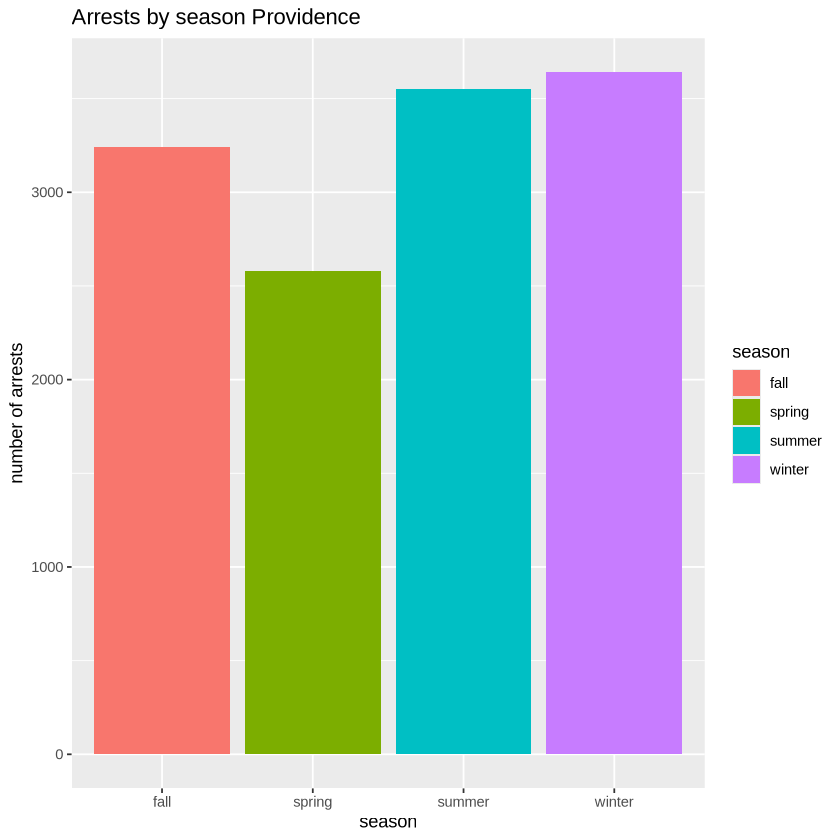

In [40]:
ggplot(season_arrests, aes( x=season, y=number_arrests, fill=season)) +
geom_bar(stat="identity") +
labs (x= "season", y = "number of arrests", title = "Arrests by season Providence")

In [48]:
#Failed attempt
#ggplot(Visual, aes(x = season, y = arrests, fill = arrests_df)) +
 #   geom_bar(stat ="identity",alpha = 0.5, colour = "grey") + #i kept getting errors, chat gpt said I needed to add "stat ="identity""
  #  labs(x="location", y= "arrests", title = "arrests expected v real summer" )

In [49]:
#Failed attempt
#ggplot(Visual) +
    #geom_density(alpha = 0.5, colour = "grey", fill = "navy", aes(x = expected_sumer)) +
   # geom_density(alpha = 0.5, colour = "grey", fill = "purple", aes(x = actual_summer)) +
   # xlim(0, 1000) +
#xlab("Expected v Actual summer arrests")
#this was another way I tried to do the visual but it will not run, please let me know how I could change this to make it better

In [50]:
#My approach 
#What I wanted to do was connect the months to seasons, which I started by attaching the season name to month.
#I got stuck, but Chat GPT and the R resources led me to decide on mapping with the match function to add a season colomn. 
#Then I wanted to do what I did in problem 1, compare the total arrests to summer (and winter given the prompt below) against the null of each respective season's ratio
#I used the bimon.test with this data to see if summer was higher than my expected 2/10- it was. I did the same for winter and got the same result of significance, just a negative relationship.
#I got stuck for a while on visuals, until I used chat gpt to see that I needed to change my Y value to arrests per season, so I groupsed by season
#I used the visual bar graph to see arrests by season, illustrating arrest count by season.


## 3. Crime rate drops during the pandemic

A study published in Nature Human Behaviour found that urban crime fell by over a third around the world during COVID-19 shutdowns. [(Nivette et al. 2021)](https://www.nature.com/articles/s41562-021-01139-z) [(press publication)](https://www.cam.ac.uk/stories/COVIDcrime). Making the same assumption with our data again, assess whether crime fell in Providence during COVID-19 shutdowns.

Note: you cannot simply count up the number of arrests or cases for each year and compare between years! If you are wondering why, check the time range of your data.

In [52]:
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")

In [53]:
#tail(arrests_df)

In [54]:
df_distinct <- arrests_df %>% distinct (arrest_date, .keep_all =TRUE)
not_pandemic<- df_distinct  %>%
#filter (year < 2020 | (year == 2020 & month < 6 )) %>%
filter (year == 2021 & month >= 3 & month <= 6) %>% #i switched to filtering this way to weight the pandemic months against a similar timeframe, I know it is not perfect but I figuered it could be a sufficent counterfactual for the test
group_by(month) %>%
 summarize(number_arrests = n())  

pandemic<- df_distinct   %>%
filter (year == 2020 & month >= 3 & month <= 6) %>%
group_by(month) %>%
 summarize(number_arrests = n())  

In [55]:
test <- t.test(not_pandemic$number_arrests,pandemic$number_arrests)
print(test)
#There is no significant drop in arrests during lockdown from this test.


	Welch Two Sample t-test

data:  not_pandemic$number_arrests and pandemic$number_arrests
t = 0.52255, df = 5.0109, p-value = 0.6236
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -83.21712 125.71712
sample estimates:
mean of x mean of y 
   252.00    230.75 



In [56]:
#here I used r help and chat gpt to do the mutate function (like I said above), I still struggle with it
#but I knew I wanted to combine my dataframes for the visual, just got stuck on how
pandemic <- pandemic %>% 
mutate(time= "pandemic")
not_pandemic <- not_pandemic %>% 
mutate(time= " not pandemic")
#here my dataframe was not working, I looked at r help and decided to try bindrows. then I asked chat gpt andit said it was "cleaner" than data.frames
arrests_total <- bind_rows (pandemic, not_pandemic)

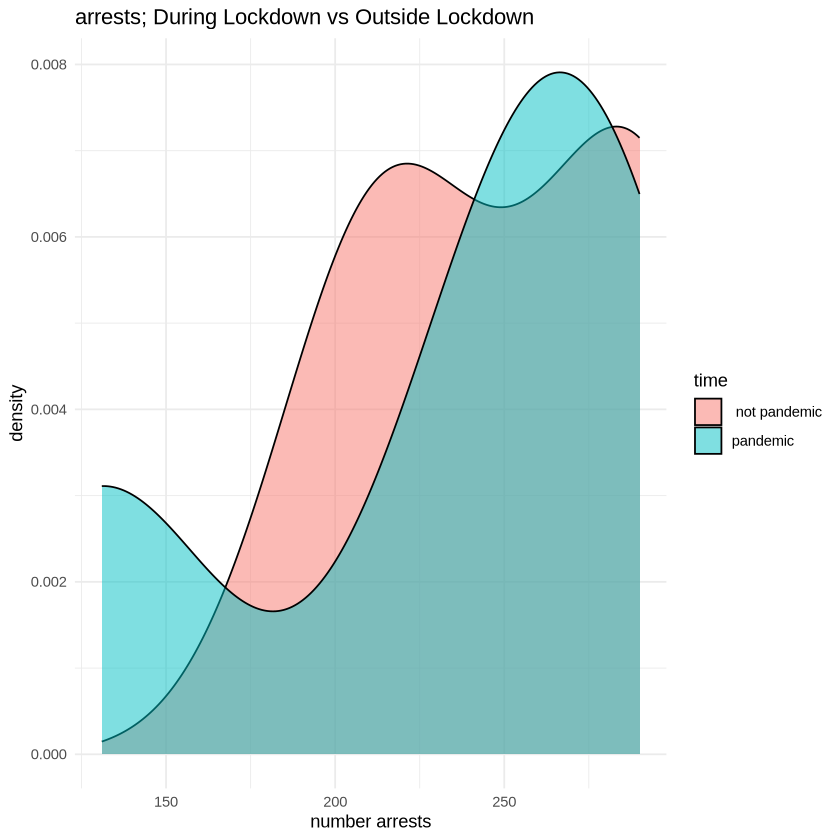

In [57]:
ggplot(arrests_total,aes(x=number_arrests,fill=time)) +
geom_density(alpha= 0.5)+
labs ( title= "arrests; During Lockdown vs Outside Lockdown",
      x = "number arrests", 
      y= "density")+
theme_minimal()

In [58]:
#My approach
#I first wanted to get the month and year of lockdown, with the filter function. (and make them distinct arrests)
#I weighted these arrests against the same month time span, just in 2021- so my results would be comparing the same time- just different years
#then I grouped by month of these filtered times and pulled the number of arrests in each month
#I tried out the t.test from class and found statistical significance
#This is where I began to get super stuck. I knew I wanted to try a density plot, but my data.frame kept returning errors
#Like I said above, online resources has me try bind_rows and mutate (honestly I am still confused here, and would like to go over it at some point- clarified in office hours!)
#Then I did my density plot. I wanted to pull from all arrests (which I created), I made my x the number of arrests from my groups, and y time which I mutated.


## 4. Outlier data

In our data, December 2019 and January 2020 seem to have an unusually high number of arrests without a corresponding spike in cases. Is there actually a significant difference between arrests in that time period and other time periods? Explore the data and come up with some hypotheses around the spike.

In [2]:
#head(arrests_df)

In [3]:
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")
df_distinct <- arrests_df %>% distinct (arrest_date, .keep_all =TRUE)
Dec19Jan20<- df_distinct %>%
filter ((month==12 & year==2019 | month==1 & year==2020))
number_december19_january20 <-nrow(Dec19Jan20)
number_total <- nrow(arrests_df)
#print (number_december19_january20)
#print(number_total)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
other_months <- number_total - number_december19_january20
#print (other_months)

In [5]:
#I used chatgpt to understand the contingency table because I was confused from online resources, turn sout it's just a table.

all_arrests <- data.frame (
    time = c("Dec19Jan20", "all other"),
    count = c(number_december19_january20, other_months)
    )
print (all_arrests)

        time count
1 Dec19Jan20   744
2  all other 12268


In [6]:
# I used chat GPT and R help to weight this
#I did proportions 
all_arrests <- all_arrests %>%
mutate (weight =count / number_total) #I am not sure if this is right but it made sense to me based off all my online resources.

In [7]:
#ok trying mutate here based off of previous questions, I want to create a coloumn to categorise my two values
df_distinct <- arrests_df %>%
mutate(time = ifelse ((month == 12 & year==2019 | month==1 & year==2020),
       "Dec19Jan20", "other" ) ) #here I got super stuck on the ifelse in mutate. I used chatgpt and r help



In [8]:
arrests_final <-matrix(all_arrests$count,nrow =1) #I used interntet to add the nrow=1 i am confused by that?
test <- chisq.test(arrests_final)
print (test)
#there is a significant difference! My hypothesis is NYE arrests in this timeframe. Often there is a massive spike in arrests for NYE parties, and I assume that is why we see it where 31Dec and 1Jan overlap


	Chi-squared test for given probabilities

data:  arrests_final
X-squared = 10206, df = 1, p-value < 2.2e-16



In [9]:
counts <- arrests_df %>% group_by(year, month) %>% count()
counts

year,month,n
<int>,<int>,<int>
2019,7,541
2019,8,652
2019,9,610
2019,10,639
2019,11,651
2019,12,900
2020,1,1202
2020,2,569
2020,3,590


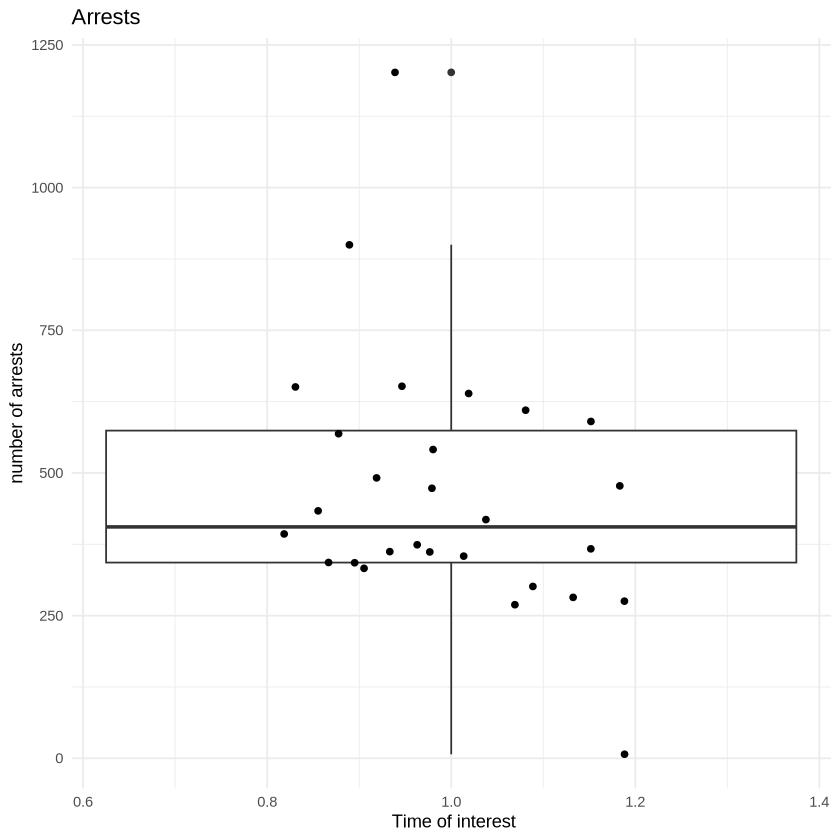

In [10]:
ggplot(counts, aes(y = n, x = 1)) +
    geom_boxplot() + 
    geom_jitter(width = 0.2) +
labs (title = "Arrests",
      x = " Time of interest",
      y = "number of arrests" ) +
theme_minimal()


In [11]:
#head (arrests_df)

In [ ]:
#My approach ( this one I think I had the hardest time with) 
#I made sure I did destinct arrests, anf then filtered for my selected timeframe
#I counted arrests, then I tried to calculate proportions by making my count based off the total of each category (i am not sure baout this- most of my understanding of thi sstep was from online resources)
#Then I made my time column to see if it was in my selected time or not
#my chi square test found a spike in crime, which i attributed to NYE
#then the box plot visulisation wa sbased off of office hours help. 

## 5. Coming up with your own question

Come up with your own question with regards to the data, and answer it with a statistical test and visualization based on what we have learned so far. What followup questions does your answer generate?

In [13]:
#are people under 30 more likely to be arrested than people over 30. count under and over 30.
library(tidyverse)
arrests_df = read.csv("pvd_arrests_2021-10-03.csv")
df_distinct <- arrests_df %>% distinct (arrest_date, .keep_all =TRUE)
age <- ifelse(df_distinct$age <= 30, "under 30", "over 30") #i googled how to structure this. 
number_arrests <- length(age)
under_30 <- sum (age == "under 30")



In [14]:
df_distinct %>% summarise(
under_30 = sum(age < 30),
over_30 = sum(age >= 30))
print(under_30)


under_30,over_30
<int>,<int>
3180,4131


[1] 3470


In [15]:
test <- binom.test(under_30, number_arrests)
print (test)
#there is no statistical significance for arrests under 30 compared to over, so we fail to reject the null "people under 30 are not more likely to be arrested than those over 30"


	Exact binomial test

data:  under_30 and number_arrests
number of successes = 3470, number of trials = 7311, p-value =
1.504e-05
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.4631245 0.4861503
sample estimates:
probability of success 
             0.4746273 



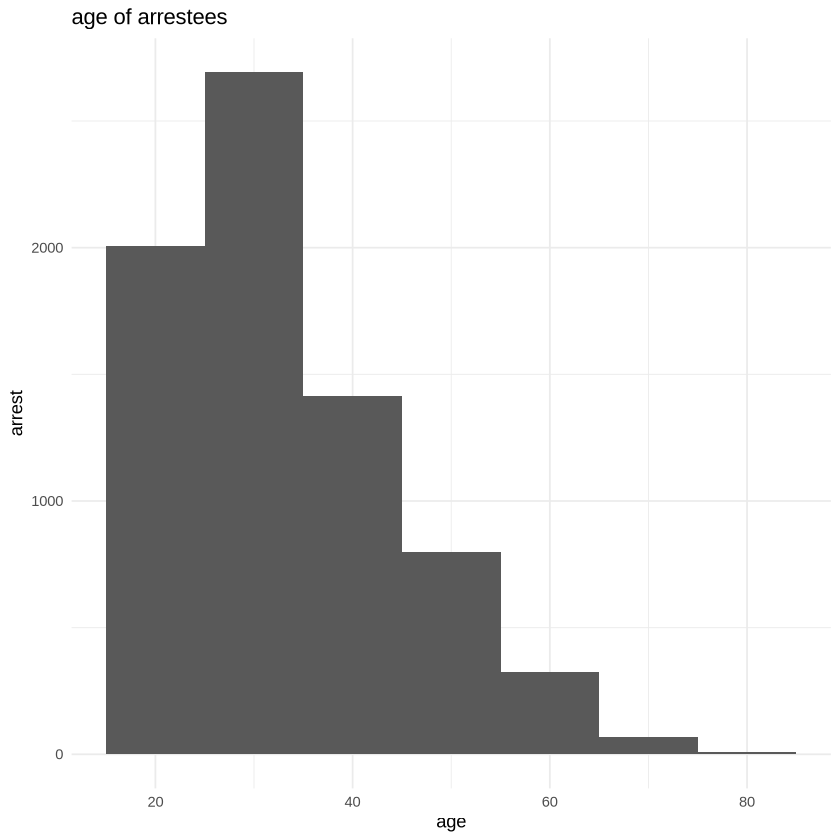

In [17]:
ggplot(df_distinct, aes (x=age)) +
geom_histogram(binwidth = 10) +
labs (title = "age of arrestees",
      x= "age",
      y = "arrest" ) +
theme_minimal()


In [ ]:
#my approach
#first I made a distinct dataframe, and then I seperates those under 30 from those over 30
#then I counted the number of arrests by age with the summarise function, just to see if there was any large discrepency
#then I ran a binomial test and found no significance
#I used a histogram to show this, because it illustrates a pretty fairly balanced distribution of arrests- explaining why there was no significance found


## Extra credit 1 (5 pts)

There is a lot of missing data in the `cases` and `arrests` dataframes. Often a question that comes up with missing data is whether it is missing at random or systematically. ([Little 1986](https://www.tandfonline.com/doi/abs/10.1080/01621459.1988.10478722)) describes a statistical test to test for whether data is missing completely at random or not. Apply the test to our data and provide your assessment of whether the data is missing or not.

In [ ]:
#I have no idea, next office hours I wouldlike to go over this.

## Extra credit 2 (5 pts)

Although we use our data to answer the questions above, it is almost certainly not the best source of data to use, just what we have available to us through public records. The field of criminology and how to define crime additionally has [fraught history](https://www.bu.edu/bulawreview/files/2020/05/02-SIMON.pdf) and [modern controversies](https://www.theguardian.com/us-news/2021/nov/07/lapd-predictive-policing-surveillance-reform) rooted in structural and political issues. What are some of the potential problems with our data for answering these questions besides missingness? What are assumptions made and potential issues with some of the questions asked in this homework?

Law enforcement itself is structurally racist, and this will inevitably impact the data we look at. People of colour are much more likely to be arrested, and I am sure if you look at the data- compared to Providence's population- arrests of Black people will be of concern. This overrepresentation of a minority population across teh country should raise concern about biased arrests and policing. 
Also (arguably) the legal system is punitive in its way of punishing poverty, which targetes those in lower socioeconomic brackets. For example, if we look at arrests, the most common reason is driving on a suspended license. This, in my opinon, is the criminilisation of poverty, as people are punished for their economic status. This categorization of poverty as criminal leads the data to reflect high arrest rates of infractions that are "criminal" in a technical sense but have no impact on public saftey. This alongside the potential overrepresentation of those in at risk communities will lead data to reflect structural inequalities, not arrests associated with criminality. 